In [2]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import pingouin as pg

df = pd.read_csv('base_datos_diabetes.csv')                            ## Carga el archivo CSV en un DataFrame de pandas
var_num = ['Edad','Frecuencia_Cardiaca_lpm','Presion_Sistolica_mmHg',
           'Presion_Diastolica_mmHg','Frecuencia_Respiratoria_rpm',
           'Saturacion_Oxigeno_pct','Horas_Sueno','Num_Hermanos']      ## Lista de variables numéricas a analizar   
def conteo(datos):
    return len(datos)                                                        ## Función para contar el número de datos en una serie

def media(datos):
    return sum(datos) / conteo(datos)                                              ## Función para calcular la media de una serie

def desvest(datos):
    media_datos = media(datos)
    suma_cuadrados = sum((x - media_datos) ** 2 for x in datos)
    return math.sqrt(suma_cuadrados / (conteo(datos)-1))

def percentil(datos, percentil):
    datos_ordenados =sorted(datos)
    n = conteo(datos)
    k = (n - 1) * (percentil / 100)
    f = math.floor(k)
    c = math.ceil(k)
    if f == c:
        return datos_ordenados[int(k)]
    else:

        d0 = datos_ordenados[int(f)] * (c - k)
        d1 = datos_ordenados[int(c)] * (k - f)
        return d0 + d1
    
grupos = df['Grupo'].unique()

#print(grupos)

for grupo in grupos:

    datos_grupo = df[df['Grupo'] == grupo]
    conteo_grupo = conteo(datos_grupo)
    #print(conteo_grupo)
    for var in var_num:
        datos_var = datos_grupo[var].dropna() # Elimina los valores NaN de la variable
        media_var = media(datos_var)
        desvest_var = desvest(datos_var)
        p25 = percentil(datos_var, 25)
        p50 = percentil(datos_var, 50)
        p75 = percentil(datos_var, 75)
        min_var = min(datos_var)
        max_var = max(datos_var)
        ##Tabla de resultados
        print(f"Grupo: {grupo}, Variable: {var}")
        print(f"Conteo: {conteo_grupo}")
        print(f"Media: {media_var:.2f}")
        print(f"Desviación Estándar: {desvest_var:.2f}")
        print(f"Percentil 25: {p25:.2f}")
        print(f"Percentil 50: {p50:.2f}")
        print(f"Percentil 75: {p75:.2f}")
        print(f"Valor Mínimo: {min_var:.2f}")
        print(f"Valor Máximo: {max_var:.2f}")
        print("-" * 40) 


                                                                


Grupo: Diabetes_Reciente, Variable: Edad
Conteo: 35
Media: 51.94
Desviación Estándar: 3.97
Percentil 25: 49.00
Percentil 50: 52.00
Percentil 75: 55.00
Valor Mínimo: 45.00
Valor Máximo: 60.00
----------------------------------------
Grupo: Diabetes_Reciente, Variable: Frecuencia_Cardiaca_lpm
Conteo: 35
Media: 81.15
Desviación Estándar: 6.91
Percentil 25: 77.85
Percentil 50: 81.80
Percentil 75: 85.45
Valor Mínimo: 64.90
Valor Máximo: 93.10
----------------------------------------
Grupo: Diabetes_Reciente, Variable: Presion_Sistolica_mmHg
Conteo: 35
Media: 137.16
Desviación Estándar: 14.05
Percentil 25: 126.30
Percentil 50: 137.10
Percentil 75: 141.50
Valor Mínimo: 116.20
Valor Máximo: 195.00
----------------------------------------
Grupo: Diabetes_Reciente, Variable: Presion_Diastolica_mmHg
Conteo: 35
Media: 86.22
Desviación Estándar: 7.96
Percentil 25: 80.55
Percentil 50: 84.20
Percentil 75: 91.85
Valor Mínimo: 75.60
Valor Máximo: 106.60
----------------------------------------
Grupo: D

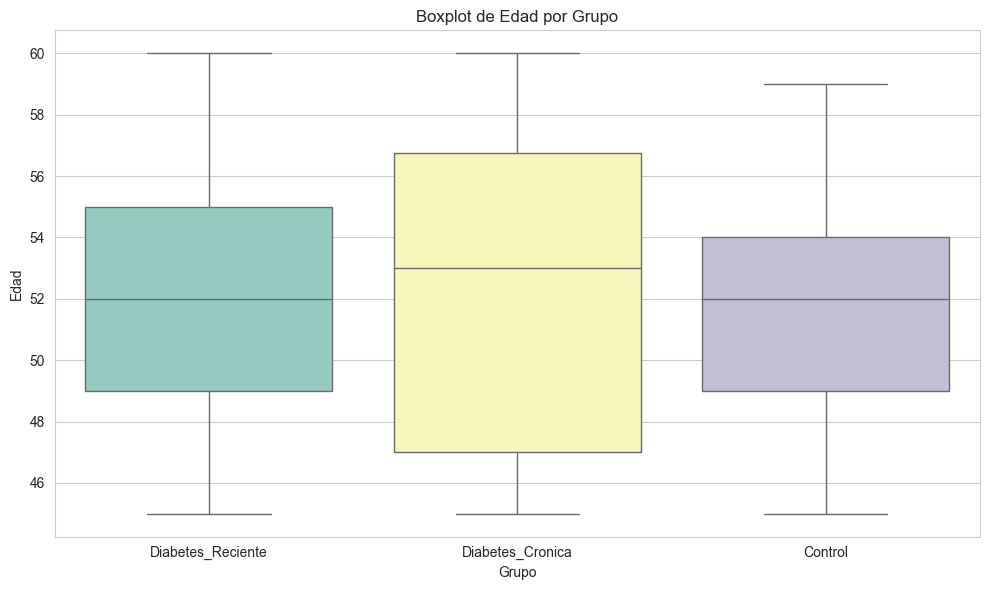

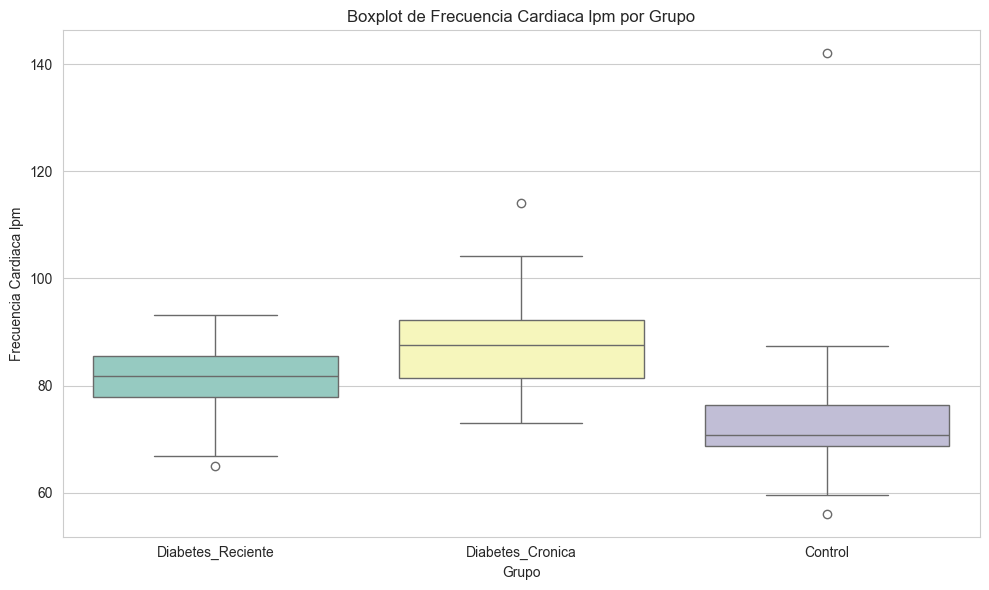

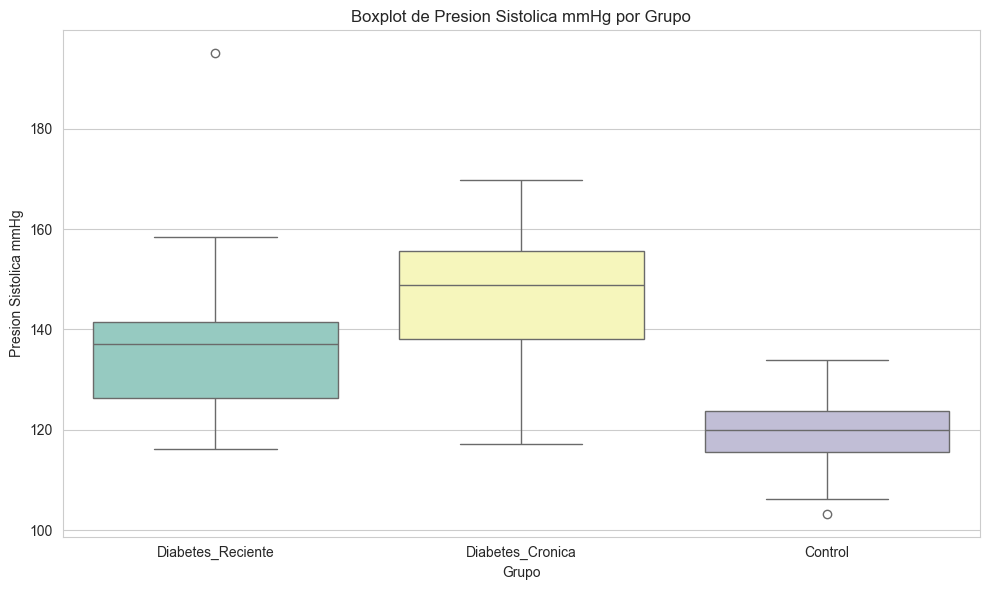

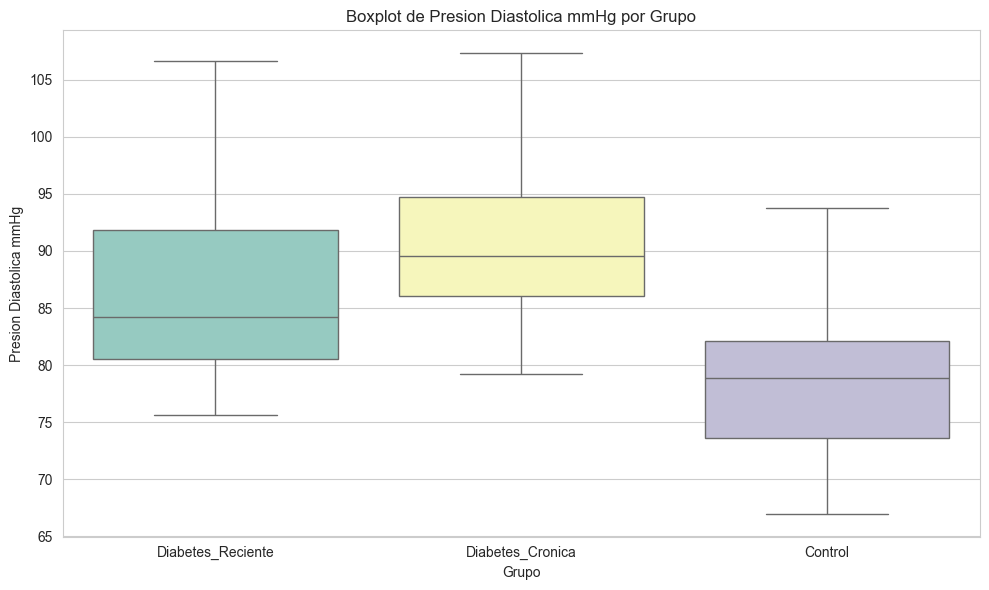

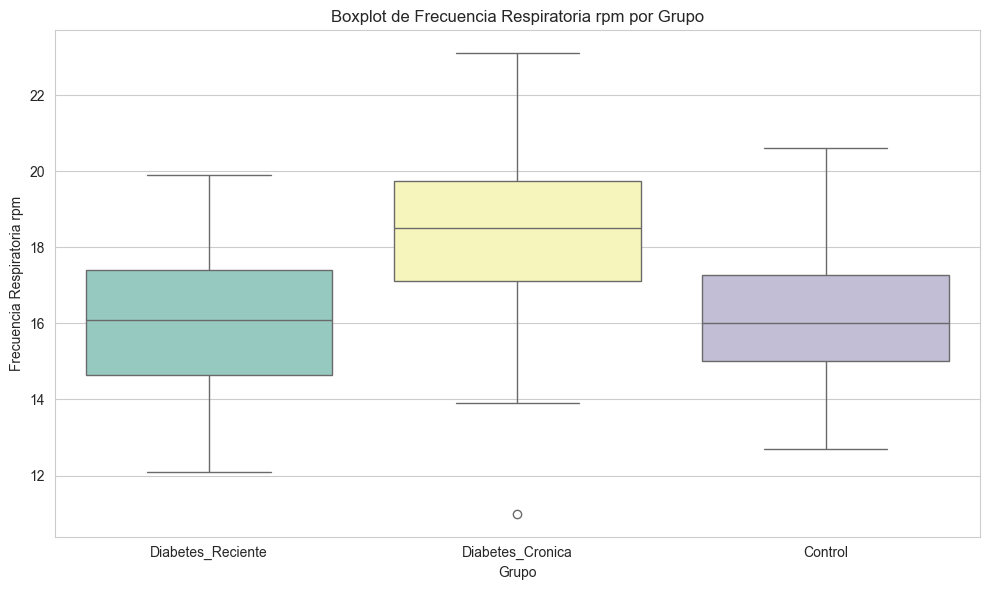

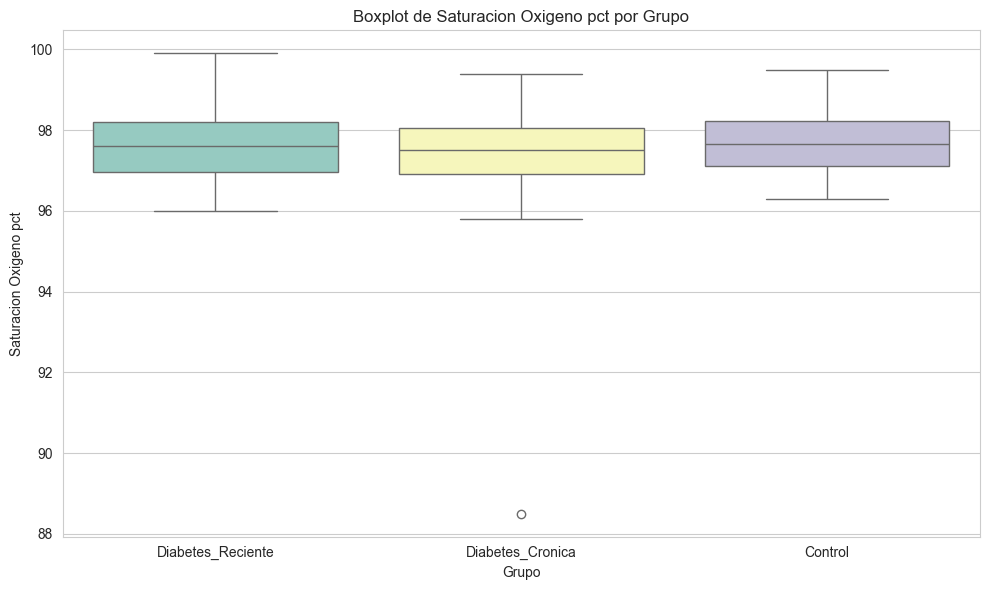

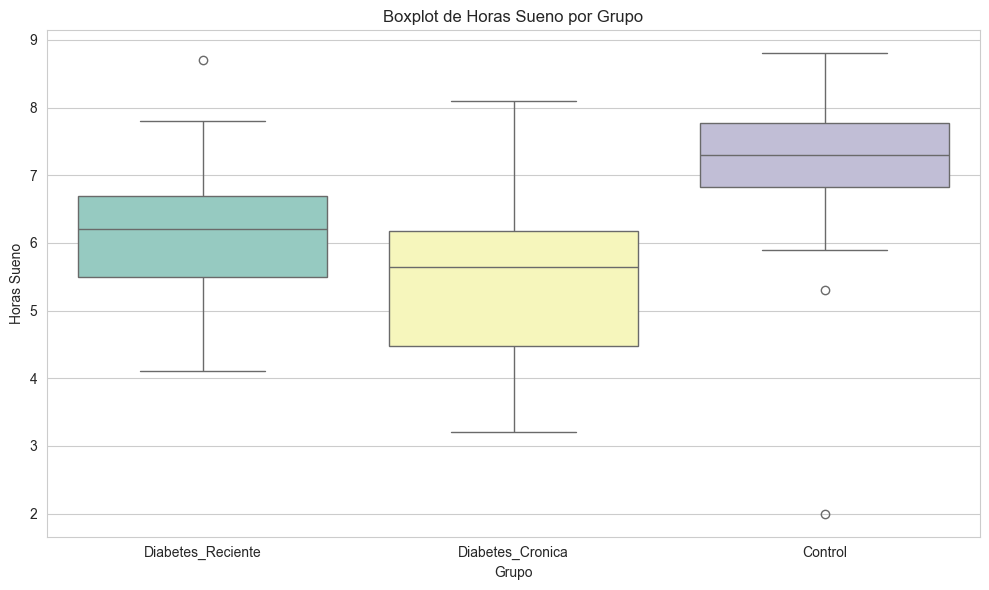

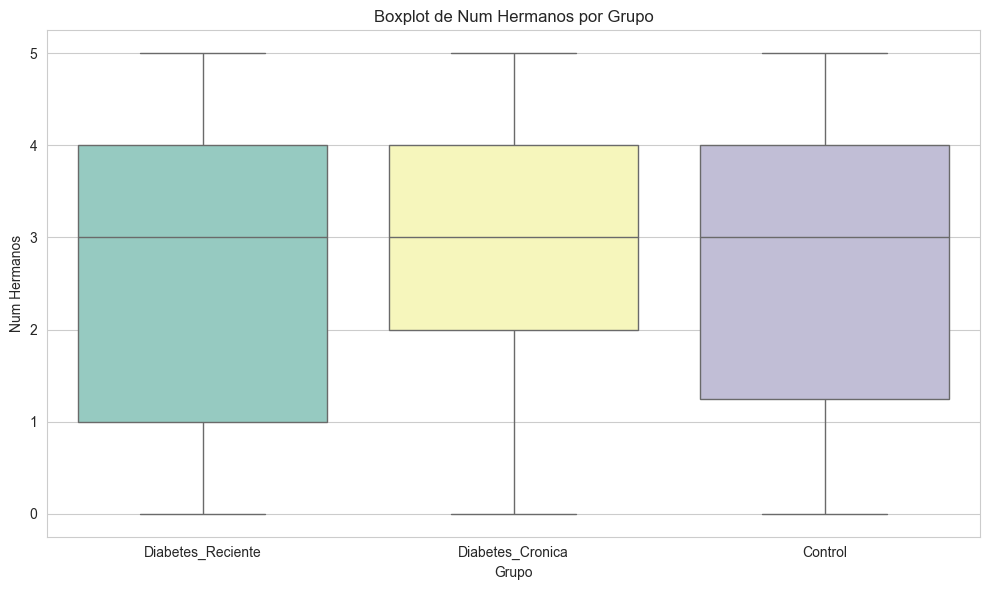

In [3]:
sns.set_style("whitegrid")

for var in var_num:
    nombre_var = var.replace('_', ' ')
    plt.figure(figsize=(10,6))
    sns.boxplot(x='Grupo', y=var, data=df, palette='Set3', hue='Grupo')
    plt.title(f'Boxplot de {nombre_var} por Grupo')
    plt.xlabel('Grupo')
    plt.ylabel(nombre_var)
    plt.tight_layout()
    plt.show()


In [4]:
alfa = 0.05
for var in var_num:
    nombre_var = var.replace('_', ' ')
    print(f"Prueba de normalidad para {nombre_var}")
    normalidad = True
    for grupo in grupos:
        datos_grupo = df[df['Grupo'] == grupo]
        estadistica_w, p_valor = stats.shapiro(datos_grupo[var])
        if p_valor < alfa:
            normalidad = False
            resultado = "No normal"
        else:
            resultado = "Normal"

        print(f"Grupo: {grupo}, Estadística W: {estadistica_w:.4f}, p-valor: {p_valor:.4f} -> {resultado}")


    print("-" * 40)
    print(f"Prueba de homeoscedasticidad para {nombre_var}")

    g1 = df[df['Grupo'] == 'Diabetes_Reciente'][var]
    g2 = df[df['Grupo'] == 'Diabetes_Cronica'][var]
    g3 = df[df['Grupo'] == 'Control'][var]

    estadistico_levene, p_valor_levene = stats.levene(g1, g2, g3)

    if p_valor_levene < alfa:
        resultado_levene = "No homocedasticidad"
    else:
        resultado_levene = "Homocedasticidad"

    print(f"Estadístico de Levene: {estadistico_levene:.4f}, p-valor: {p_valor_levene:.4f} -> {resultado_levene}")
    print("-" * 40)
    if normalidad and resultado_levene == "Homocedasticidad":
        print( "Diagnostico: Se cumplen los supuestos para ANOVA")
    else:
        print("Diagnostico: No se cumplen los supuestos para ANOVA")
    print("-" * 40)
    

Prueba de normalidad para Edad
Grupo: Diabetes_Reciente, Estadística W: 0.9700, p-valor: 0.4442 -> Normal
Grupo: Diabetes_Cronica, Estadística W: 0.8827, p-valor: 0.0005 -> No normal
Grupo: Control, Estadística W: 0.9480, p-valor: 0.0284 -> No normal
----------------------------------------
Prueba de homeoscedasticidad para Edad
Estadístico de Levene: 6.0043, p-valor: 0.0032 -> No homocedasticidad
----------------------------------------
Diagnostico: No se cumplen los supuestos para ANOVA
----------------------------------------
Prueba de normalidad para Frecuencia Cardiaca lpm
Grupo: Diabetes_Reciente, Estadística W: 0.9672, p-valor: 0.3711 -> Normal
Grupo: Diabetes_Cronica, Estadística W: 0.9693, p-valor: 0.3122 -> Normal
Grupo: Control, Estadística W: 0.6306, p-valor: 0.0000 -> No normal
----------------------------------------
Prueba de homeoscedasticidad para Frecuencia Cardiaca lpm
Estadístico de Levene: 0.5255, p-valor: 0.5926 -> Homocedasticidad
--------------------------------

In [5]:
vars_sig = []
vars_ns = []

for var in var_num:
    g1 = df[df['Grupo'] == 'Diabetes_Reciente'][var]
    g2 = df[df['Grupo'] == 'Diabetes_Cronica'][var]
    g3 = df[df['Grupo'] == 'Control'][var]

    F, p_valor = stats.f_oneway(g1, g2, g3)
    all_data = np.concatenate([g1, g2, g3])
    media_total = np.mean(all_data)
    SS_between = (len(g1) * (np.mean(g1) - media_total) ** 2 +
                  len(g2) * (np.mean(g2) - media_total) ** 2
                    + len(g3) * (np.mean(g3) - media_total) ** 2)
    SS_total = sum((x - media_total) ** 2 for x in all_data)
    eta_squared = SS_between / SS_total if SS_total > 0 else 0

    sig = "Significativo" if p_valor < alfa else "No significativo"
    print(f"ANOVA para {var}: F={F:.4f}, p-valor={p_valor:.4f} -> {sig}, Eta²={eta_squared:.4f}")
    if p_valor < alfa:
        vars_sig.append(var)
    else:
        vars_ns.append(var)

print("\nVariables con diferencias significativas entre grupos:")
for var in vars_sig:
    print(f"- {var}")
print("\nVariables sin diferencias significativas entre grupos:")
for var in vars_ns:
    print(f"- {var}")

ANOVA para Edad: F=0.0515, p-valor=0.9498 -> No significativo, Eta²=0.0008
ANOVA para Frecuencia_Cardiaca_lpm: F=28.0790, p-valor=0.0000 -> Significativo, Eta²=0.3117
ANOVA para Presion_Sistolica_mmHg: F=67.8357, p-valor=0.0000 -> Significativo, Eta²=0.5225
ANOVA para Presion_Diastolica_mmHg: F=37.1794, p-valor=0.0000 -> Significativo, Eta²=0.3749
ANOVA para Frecuencia_Respiratoria_rpm: F=19.4240, p-valor=0.0000 -> Significativo, Eta²=0.2386
ANOVA para Saturacion_Oxigeno_pct: F=0.8614, p-valor=0.4251 -> No significativo, Eta²=0.0137
ANOVA para Horas_Sueno: F=28.7801, p-valor=0.0000 -> Significativo, Eta²=0.3170
ANOVA para Num_Hermanos: F=0.1464, p-valor=0.8639 -> No significativo, Eta²=0.0024

Variables con diferencias significativas entre grupos:
- Frecuencia_Cardiaca_lpm
- Presion_Sistolica_mmHg
- Presion_Diastolica_mmHg
- Frecuencia_Respiratoria_rpm
- Horas_Sueno

Variables sin diferencias significativas entre grupos:
- Edad
- Saturacion_Oxigeno_pct
- Num_Hermanos


In [10]:
for var in vars_sig:
    nombre_var = var.replace('_', ' ')
    print(f"Prueba post-hoc de Tukey para {nombre_var}")
    tukey = pg.pairwise_tukey(data=df, dv=var, between='Grupo')
    print(tukey[['A', 'B', 'mean_A', 'mean_B', 'diff', 'se', 'T', 'p_tukey']].round(4).to_string(index=False))
    print("-" * 40)

    print(f"Prueba post-hoc de Games-Howell para {nombre_var}")
    gh = pg.pairwise_gameshowell(data=df, dv=var, between='Grupo')
    #print(gh[['A', 'B', 'mean_A', 'mean_B', 'diff', 'se', 'T', 'p-val']].round(4).to_string(index=False))
    print(gh[['A', 'B', 'mean_A', 'mean_B', 'diff', 'se', 'T', 'pval']].round(4).to_string(index=False))
    print("-" * 40)


Prueba post-hoc de Tukey para Frecuencia Cardiaca lpm
               A                 B  mean_A  mean_B     diff     se       T  p_tukey
         Control  Diabetes_Cronica 73.1120 88.3476 -15.2356 2.0388 -7.4728   0.0000
         Control Diabetes_Reciente 73.1120 81.1543  -8.0423 2.1468 -3.7462   0.0008
Diabetes_Cronica Diabetes_Reciente 88.3476 81.1543   7.1933 2.2294  3.2266   0.0045
----------------------------------------
Prueba post-hoc de Games-Howell para Frecuencia Cardiaca lpm
               A                 B  mean_A  mean_B     diff     se       T   pval
         Control  Diabetes_Cronica 73.1120 88.3476 -15.2356 2.1723 -7.0135 0.0000
         Control Diabetes_Reciente 73.1120 81.1543  -8.0423 2.0333 -3.9552 0.0005
Diabetes_Cronica Diabetes_Reciente 88.3476 81.1543   7.1933 1.8193  3.9539 0.0005
----------------------------------------
Prueba post-hoc de Tukey para Presion Sistolica mmHg
               A                 B   mean_A   mean_B     diff     se        T  p_tukey